In [10]:
import os
import pandas as pd
import ROOT
import pickle
import csv
import uproot
import numpy as np
import mplhep as hep
import awkward as ak
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.optimize import curve_fit
from array import array
from tqdm import trange, tqdm
import random
import time 
import hist
from uncertainties import unumpy as unp
from IPython.display import display, Image

In [2]:
def normalize_histogram_with_uncertainty(histogram, input_format=None, output_format=None, flow=False):
    """
    Normalize a histogram with uncertainty propagation and support for uproot, ROOT, and hist.Hist formats.

    Args:
        histogram: Input histogram (uproot, ROOT, or hist.Hist).
        input_format (str): Format of the input histogram ("uproot", "ROOT", or "hist.Hist").
        output_format (str): Desired format of the output histogram ("uproot", "ROOT", or "hist.Hist").
        flow (bool): Whether to include underflow and overflow bins in normalization.

    Returns:
        Normalized histogram in the specified output format.
    """
    # Detect input format if not specified
    if input_format is None:
        if isinstance(histogram, hist.Hist):
            input_format = "hist"
        elif isinstance(histogram, ROOT.TH1):
            input_format = "ROOT"
        elif hasattr(histogram, "values") and hasattr(histogram, "axes"):
            input_format = "uproot"
        else:
            raise ValueError("Unable to detect input histogram format. Specify input_format.")

    # Extract values, variances, and edges based on input format
    if input_format == "hist":
        values = histogram.values(flow=flow)
        variances = histogram.variances(flow=flow)
        edges = histogram.axes[0].edges
        hist_name = "normalized by bin width"
    elif input_format == "ROOT":
        nbins = histogram.GetNbinsX()
        values = np.array([histogram.GetBinContent(i + 1) for i in range(nbins)])
        variances = np.array([histogram.GetBinError(i + 1)**2 for i in range(nbins)])
        edges = np.array([histogram.GetBinLowEdge(i + 1) for i in range(nbins + 1)])
        hist_name = histogram.GetName()
    elif input_format == "uproot":
        values = histogram.values()
        variances = histogram.variances()
        edges = histogram.axes[0].edges()
        hist_name = histogram.to_hist().name
    else:
        raise ValueError("Unsupported input_format. Use 'uproot', 'ROOT', or 'hist.Hist'.")

    #print(edges)

    # Handle cases with no entries
    total_value = np.sum(values)
    if total_value == 0:
        return histogram  # Return as-is if total is zero

    # Create array with uncertainties using unumpy
    values_with_uncert = unp.uarray(values, np.sqrt(variances))

    # Normalize the values with uncertainty propagation
    normalized_values = values_with_uncert / total_value

    # Determine output format if not provided
    if output_format is None:
        output_format = input_format

    # Generate the normalized histogram based on requested output format
    if output_format == "hist":
        normalized_hist = hist.Hist(
            histogram.axes[0],
            name=hist_name, 
            storage=hist.storage.Weight()
        )
        normalized_hist[...] = (unp.nominal_values(normalized_values),
                                unp.std_devs(normalized_values)**2)
        return normalized_hist

    elif output_format == "ROOT":
        h_density = ROOT.TH1D(hist_name, hist_name, len(values), edges[0], edges[-1])
        for i in range(len(values)):
            h_density.SetBinContent(i + 1, unp.nominal_values(normalized_values)[i])
            h_density.SetBinError(i + 1, unp.std_devs(normalized_values)[i])
        return h_density

    elif output_format == "uproot":
        h_density = hist.Hist.new.Reg(len(values), edges[0], edges[-1], name=hist_name).Double()
        h_density.view(flow=False)[...] = unp.nominal_values(normalized_values)
        h_density.variances(flow=False)[...] = unp.std_devs(normalized_values)**2
        return h_density

    else:
        raise ValueError("Unsupported output_format. Use 'uproot', 'ROOT', or 'hist.Hist'.")

# Example usage
# Assuming `h` is a histogram in one of the supported formats
# normalized_h = normalize_histogram_with_uncertainty(h, input_format="ROOT", output_format="hist.Hist")


In [69]:
merged_hists['gen_b1j'].label

'gen_b1j'

In [206]:
import numpy as np
import hist
import uproot
import pickle
from collections import defaultdict
from uncertainties import unumpy as unp

op_values = ['-8', '-4', '-2', '0', '2', '4', '8']

for value in op_values:
    
    path = f"/depot/cms/top/he614/notebooks/EFT_FullRun2/histogram_output_2016*VFP_partonEFT*{value}*/Nominal/*plustau*"
    plustau_paths = !realpath {path}

    merged_hists = defaultdict(lambda: None)

    for path in plustau_paths:
        with open(path, "rb") as f:
            hist_dict = pickle.load(f)

            for var, h in hist_dict.items():
                if merged_hists[var] is None:
                    merged_hists[var] = h.copy()
                else:
                    merged_hists[var] += h

    norm_values_all = []
    norm_variances_all = []
    xy_labels = []

    for var_name, h in merged_hists.items():
        bin_edges = h.axes[0].edges
        bin_widths = np.diff(bin_edges)

        values = h.values()
        variances = h.variances()

        assert values.shape[0] == bin_widths.shape[0], f"Bin count mismatch for {var_name}"

        uvals = unp.uarray(values, np.sqrt(variances))
        normed = uvals / np.sum(uvals) / bin_widths  # Normalize to area 1 and per unit x

        norm_values_all.append(unp.nominal_values(normed))
        norm_variances_all.append(unp.std_devs(normed)**2)

        for i in range(len(values)):
            label = f"{var_name}, bin {i}"
            xy_labels.append(label)

    # Concatenate all normalized bins into flat arrays
    norm_values_flat = np.concatenate(norm_values_all)
    norm_variances_flat = np.concatenate(norm_variances_all)

    # Create unified histogram with dummy unit-width axis
    n_bins = len(norm_values_flat)
    bin_edges_flat = np.arange(n_bins + 1)

    big_hist = hist.Hist(
        hist.axis.Variable(bin_edges_flat, name="observable"),
        storage=hist.storage.Weight()
    )
    values_with_variances = np.array(
        [(val, var) for val, var in zip(norm_values_flat, norm_variances_flat)],
        dtype=[("value", "f8"), ("variance", "f8")]
    )
    big_hist[...] = values_with_variances

    with uproot.recreate(f"concatenated_histograms_ctg{value}.root") as fout:
        fout["diff_cross_section"] = big_hist

    print(f"[ctG = {value}] Saved normalized histogram with {n_bins} bins.")

# Optional: reduce bin labels (e.g., drop bin 1 of every var)
xy_labels_reduced = [
    label.replace('gen_', '').replace(', bin', '')
    for i, label in enumerate(xy_labels) if i % 6 != 1
]


[ctG = -8] Saved normalized histogram with 228 bins.
[ctG = -4] Saved normalized histogram with 228 bins.
[ctG = -2] Saved normalized histogram with 228 bins.
[ctG = 0] Saved normalized histogram with 228 bins.
[ctG = 2] Saved normalized histogram with 228 bins.
[ctG = 4] Saved normalized histogram with 228 bins.
[ctG = 8] Saved normalized histogram with 228 bins.


In [259]:
!realpath .

/depot/cms/top/he614/Top_Spin_Corr_Run2_April_2023/CMSSW_10_6_30/src/EFTFitter/exec


In [256]:
merged_hists.keys()

dict_keys(['gen_b1k', 'gen_b2k', 'gen_b1r', 'gen_b2r', 'gen_b1n', 'gen_b2n', 'gen_b1j', 'gen_b2j', 'gen_b1q', 'gen_b2q', 'gen_c_kk', 'gen_c_rr', 'gen_c_nn', 'gen_c_Prk', 'gen_c_Mrk', 'gen_c_Pnr', 'gen_c_Mnr', 'gen_c_Pnk', 'gen_c_Mnk', 'gen_c_kj', 'gen_c_rq', 'gen_c_han', 'gen_c_tra', 'gen_c_sca', 'gen_c_Prj', 'gen_c_Mrj', 'gen_c_kjL', 'gen_c_rqL', 'gen_c_rkP', 'gen_c_rkM', 'gen_c_nrP', 'gen_c_nrM', 'gen_c_nkP', 'gen_c_nkM', 'gen_ll_cHel', 'gen_ll_cLab', 'gen_llbar_delta_phi', 'gen_llbar_delta_eta'])

In [85]:
hist_stat['stat_1D_variables;1']['CovMatrix_Norm'].array()

<Array [[4.09e-05, -1.55e-05, ..., -1.34e-06], ...] type='228 * 228 * float64'>

# Prepare SM 1D concatenated histogram √

In [79]:
hist_syst['syst_1D_variables'].keys()

['hnom_AllVar',
 'CorrMatrix',
 'CovMatrix',
 'hnom_AllVar_Norm',
 'CovMatrix_Norm',
 'CorrMatrix_Norm']

In [212]:
# Re-import required libraries after reset
import uproot
import numpy as np
import hist

# Load ROOT files
hist_stat = uproot.open('/depot/cms/top/dawoodo/fullRun2_UL_September2024_unfolding/CMSSW_10_6_30/src/TopAnalysis/Configuration/analysis/diLeptonic/stat_gigantic_matrix_2016.root')
hist_syst = uproot.open('/depot/cms/top/dawoodo/fullRun2_UL_September2024_unfolding/CMSSW_10_6_30/src/TopAnalysis/Configuration/analysis/diLeptonic/syst_gigantic_matrix_2016.root')

# Extract arrays
central_values = hist_syst['syst_1D_variables']['hnom_AllVar_Norm'].array()
print("central values", np.sum(central_values))
stat_cov = hist_stat['stat_1D_variables']['CovMatrix_Norm'].array()
syst_cov = hist_syst['syst_1D_variables']['CovMatrix_Norm'].array()

# Total uncertainties
stat_uncert = np.sqrt(np.diag(stat_cov))
syst_uncert = np.sqrt(np.diag(syst_cov))
total_uncert = np.sqrt(stat_uncert**2 + syst_uncert**2)

# Observable structure
bins_per_obs = 6
n_total_bins = len(central_values)
n_observables = n_total_bins // bins_per_obs

# Observable names in correct order
observable_names = [
    'gen_b1k', 'gen_b2k', 'gen_b1r', 'gen_b2r', 'gen_b1n', 'gen_b2n',
    'gen_b1j', 'gen_b2j', 'gen_b1q', 'gen_b2q',
    'gen_c_kk', 'gen_c_rr', 'gen_c_nn', 'gen_c_Prk', 'gen_c_Mrk',
    'gen_c_Pnr', 'gen_c_Mnr', 'gen_c_Pnk', 'gen_c_Mnk',
    'gen_c_kj', 'gen_c_rq', 'gen_c_han', 'gen_c_tra', 'gen_c_sca',
    'gen_c_Prj', 'gen_c_Mrj', 'gen_c_kjL', 'gen_c_rqL',
    'gen_c_rkP', 'gen_c_rkM', 'gen_c_nrP', 'gen_c_nrM',
    'gen_c_nkP', 'gen_c_nkM', 'gen_ll_cHel', 'gen_ll_cLab',
    'gen_llbar_delta_phi', 'gen_llbar_delta_eta',
]
assert n_observables == len(observable_names), "Mismatch between observable count and names"

# Variable bin edges per observable
parton_variable_axes = {
    name: np.linspace(-1.0, 1.0, 7) for name in observable_names
}
# Special overrides
parton_variable_axes["gen_llbar_delta_phi"] = np.linspace(0.0, np.pi, 7)
parton_variable_axes["gen_llbar_delta_eta"] = np.linspace(0.0, 5.0, 7)

# --- Compute relative uncertainties per bin ---
rel_uncert_all = total_uncert / central_values 

print("\n=== Relative Uncertainties (per bin) ===")
for i, (obs_idx, rel) in enumerate(zip(range(n_total_bins), rel_uncert_all)):
    obs_name = observable_names[obs_idx // bins_per_obs]
    bin_idx = obs_idx % bins_per_obs
    #print(f"{obs_name:<20} [bin {bin_idx}]  Rel. Unc. = {rel:.2%}")

with open("rel_uncert_table.tex", "w") as f:
    f.write("\\begin{longtable}{llr}\n")
    f.write("\\caption{Relative Uncertainties per Bin (Stat $\\oplus$ Syst)} \\\\\n")
    f.write("\\toprule\nObservable & Bin & Rel. Uncertainty \\\\\n\\midrule\n\\endfirsthead\n")
    f.write("\\toprule\nObservable & Bin & Rel. Uncertainty \\\\\n\\midrule\n\\endhead\n")
    for i, rel in enumerate(rel_uncert_all):
        obs = observable_names[i // 6].replace("_", "\\_")
        b = i % 6
        f.write(f"{obs} & {b} & {rel * 100:.2f}\\% \\\\\n")
    f.write("\\bottomrule\n\\end{longtable}\n")

# Dictionary to hold normalized individual histograms
individual_histograms = {}
norm_values_all = []
norm_variances_all = []

for i, name in enumerate(observable_names):
    start = i * bins_per_obs
    end = (i + 1) * bins_per_obs
    values_i = central_values[start:end]
    errors_i = total_uncert[start:end]
    edges_i = parton_variable_axes[name]

    hist_i = hist.Hist(
        hist.axis.Variable(edges_i, name=name),
        storage=hist.storage.Weight()
    )
    values_var_i = np.array(
        [(val, err**2) for val, err in zip(values_i, errors_i)],
        dtype=[("value", "f8"), ("variance", "f8")]
    )
    hist_i[...] = values_var_i

    # --- Normalize using bin width scheme ---
    bin_edges = hist_i.axes[0].edges
    bin_widths = np.diff(bin_edges)

    nominal = unp.uarray(values_i, errors_i)
    area = sum(nominal)

    normed = nominal / area / bin_widths
    normed_values = unp.nominal_values(normed)
    normed_variances = unp.std_devs(normed) ** 2

    # Store normalized histogram
    hist_normed = hist.Hist(
        hist.axis.Variable(edges_i, name=name),
        storage=hist.storage.Weight()
    )
    normed_array = np.array(
        [(v, var) for v, var in zip(normed_values, normed_variances)],
        dtype=[("value", "f8"), ("variance", "f8")]
    )
    hist_normed[...] = normed_array
    individual_histograms[name] = hist_normed

    # Store flattened data for concatenation
    norm_values_all.append(normed_values)
    norm_variances_all.append(normed_variances)

# --- Create concatenated 1D histogram with index bins ---
norm_values_flat = np.concatenate(norm_values_all)
norm_variances_flat = np.concatenate(norm_variances_all)

n_bins = len(norm_values_flat)
index_edges = np.arange(n_bins + 1)  # index-based bins

hist_concat = hist.Hist(
    hist.axis.Variable(index_edges, name="observable"),
    storage=hist.storage.Weight()
)
concat_array = np.array(
    [(v, var) for v, var in zip(norm_values_flat, norm_variances_flat)],
    dtype=[("value", "f8"), ("variance", "f8")]
)
hist_concat[...] = concat_array

# --- Save all to ROOT ---
out_root = "concatenated_histograms.root"
with uproot.recreate(out_root) as fout:
    fout["diff_cross_section"] = hist_concat
    for name, h in individual_histograms.items():
        fout[name] = h

print(f"Saved normalized histograms to: {out_root}")

central values 37.999999999999964

=== Relative Uncertainties (per bin) ===
Saved normalized histograms to: concatenated_histograms.root


In [241]:
!realpath concatenated_histograms.root

/depot/cms/top/he614/Top_Spin_Corr_Run2_April_2023/CMSSW_10_6_30/src/EFTFitter/exec/concatenated_histograms.root


Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.6000000000000

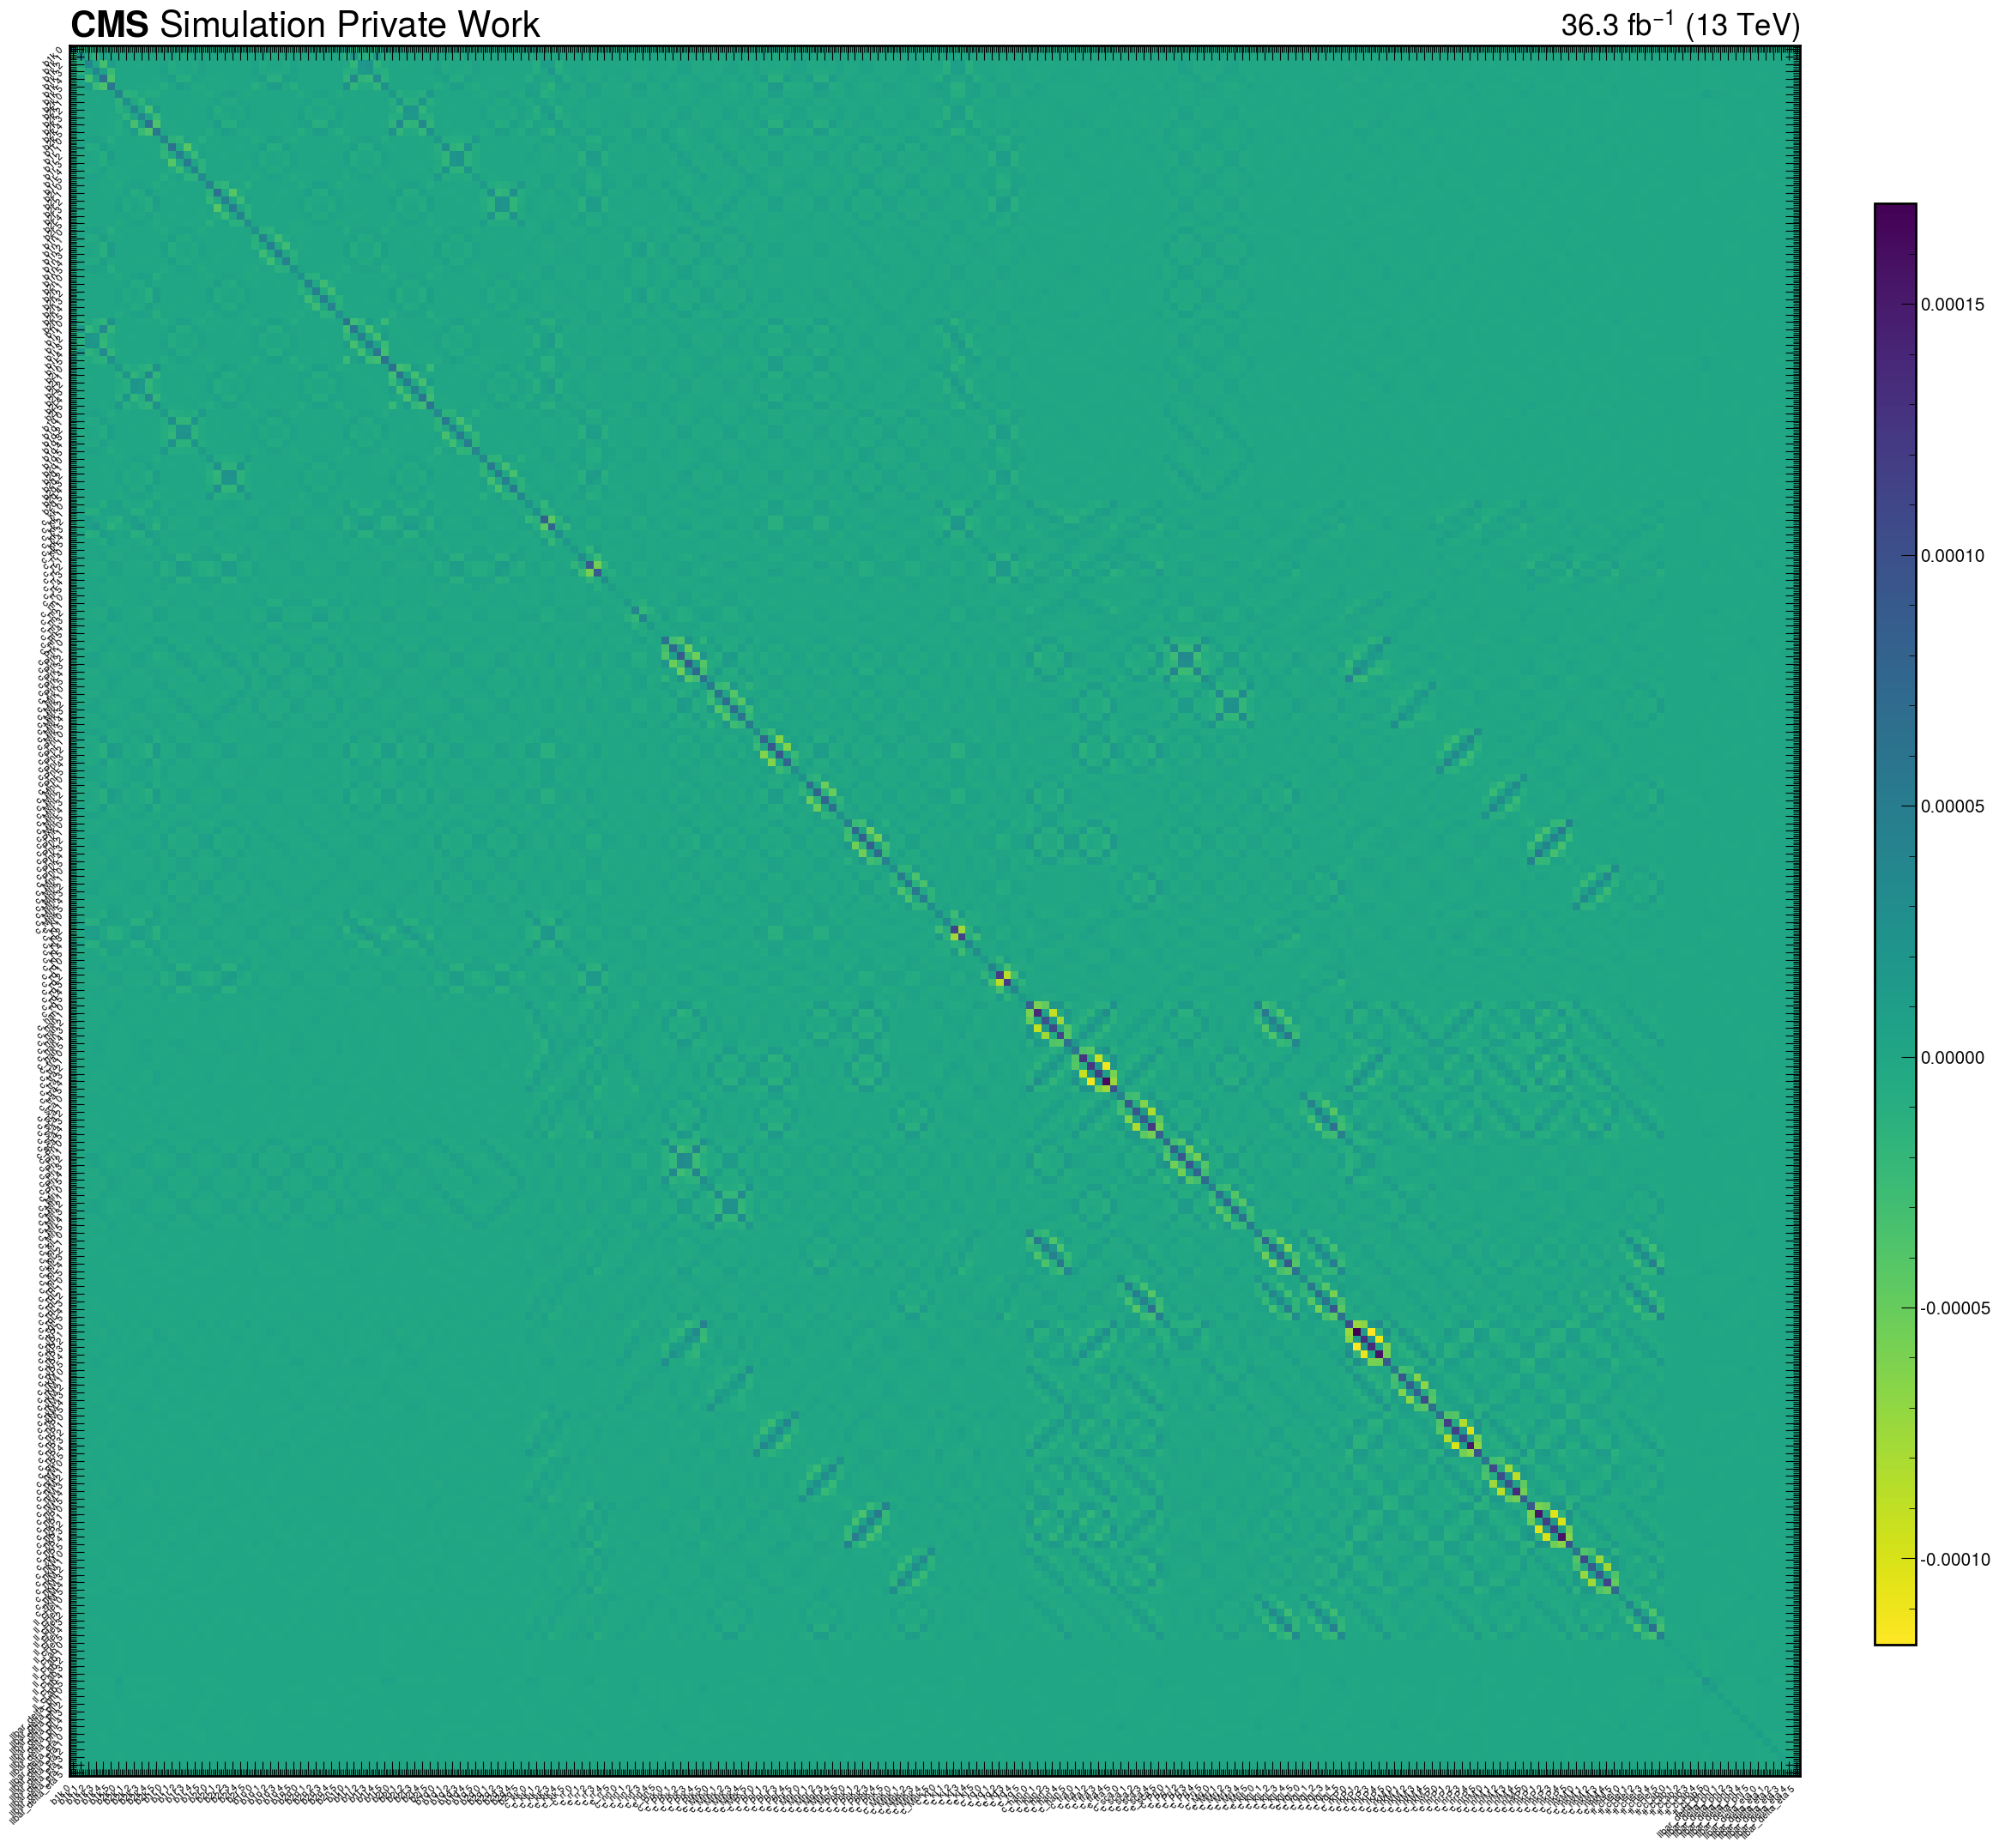

In [131]:
# Load ROOT files
hist_stat = uproot.open('/depot/cms/top/dawoodo/fullRun2_UL_September2024_unfolding/CMSSW_10_6_30/src/TopAnalysis/Configuration/analysis/diLeptonic/stat_gigantic_matrix_2016.root')
hist_syst = uproot.open('/depot/cms/top/dawoodo/fullRun2_UL_September2024_unfolding/CMSSW_10_6_30/src/TopAnalysis/Configuration/analysis/diLeptonic/syst_gigantic_matrix_2016.root')

stat_cov_matrix = [] 
stat_cov_matrix = hist_stat["stat_1D_variables;1"]["CovMatrix_Norm"].array()

# Flip the matrix vertically
#stat_cov_matrix = np.flipud(stat_cov_matrix)

# Shape info
n_bins = len(stat_cov_matrix)

# Plotting
fig, axs = plt.subplots(1, 1, figsize=(24, 24))

im = axs.imshow(stat_cov_matrix, cmap='viridis_r')

axs.set_title(r"$\mathbf{CMS}$ Simulation Private Work", fontsize=30, loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")

axs.set_xticks(np.arange(n_bins))
axs.set_xticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

axs.set_yticks(np.arange(n_bins))
axs.set_yticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=15)

axs.set_ylim(n_bins - 0.5, -0.5)  # to keep y-axis in correct order

# Optional: save to PDF
plt.savefig('stat_matrix_from_root.pdf')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # adjust for colorbar
plt.show()

Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.60000000000002]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1141 ticks ([-0.4, ..., 227.6000000000000

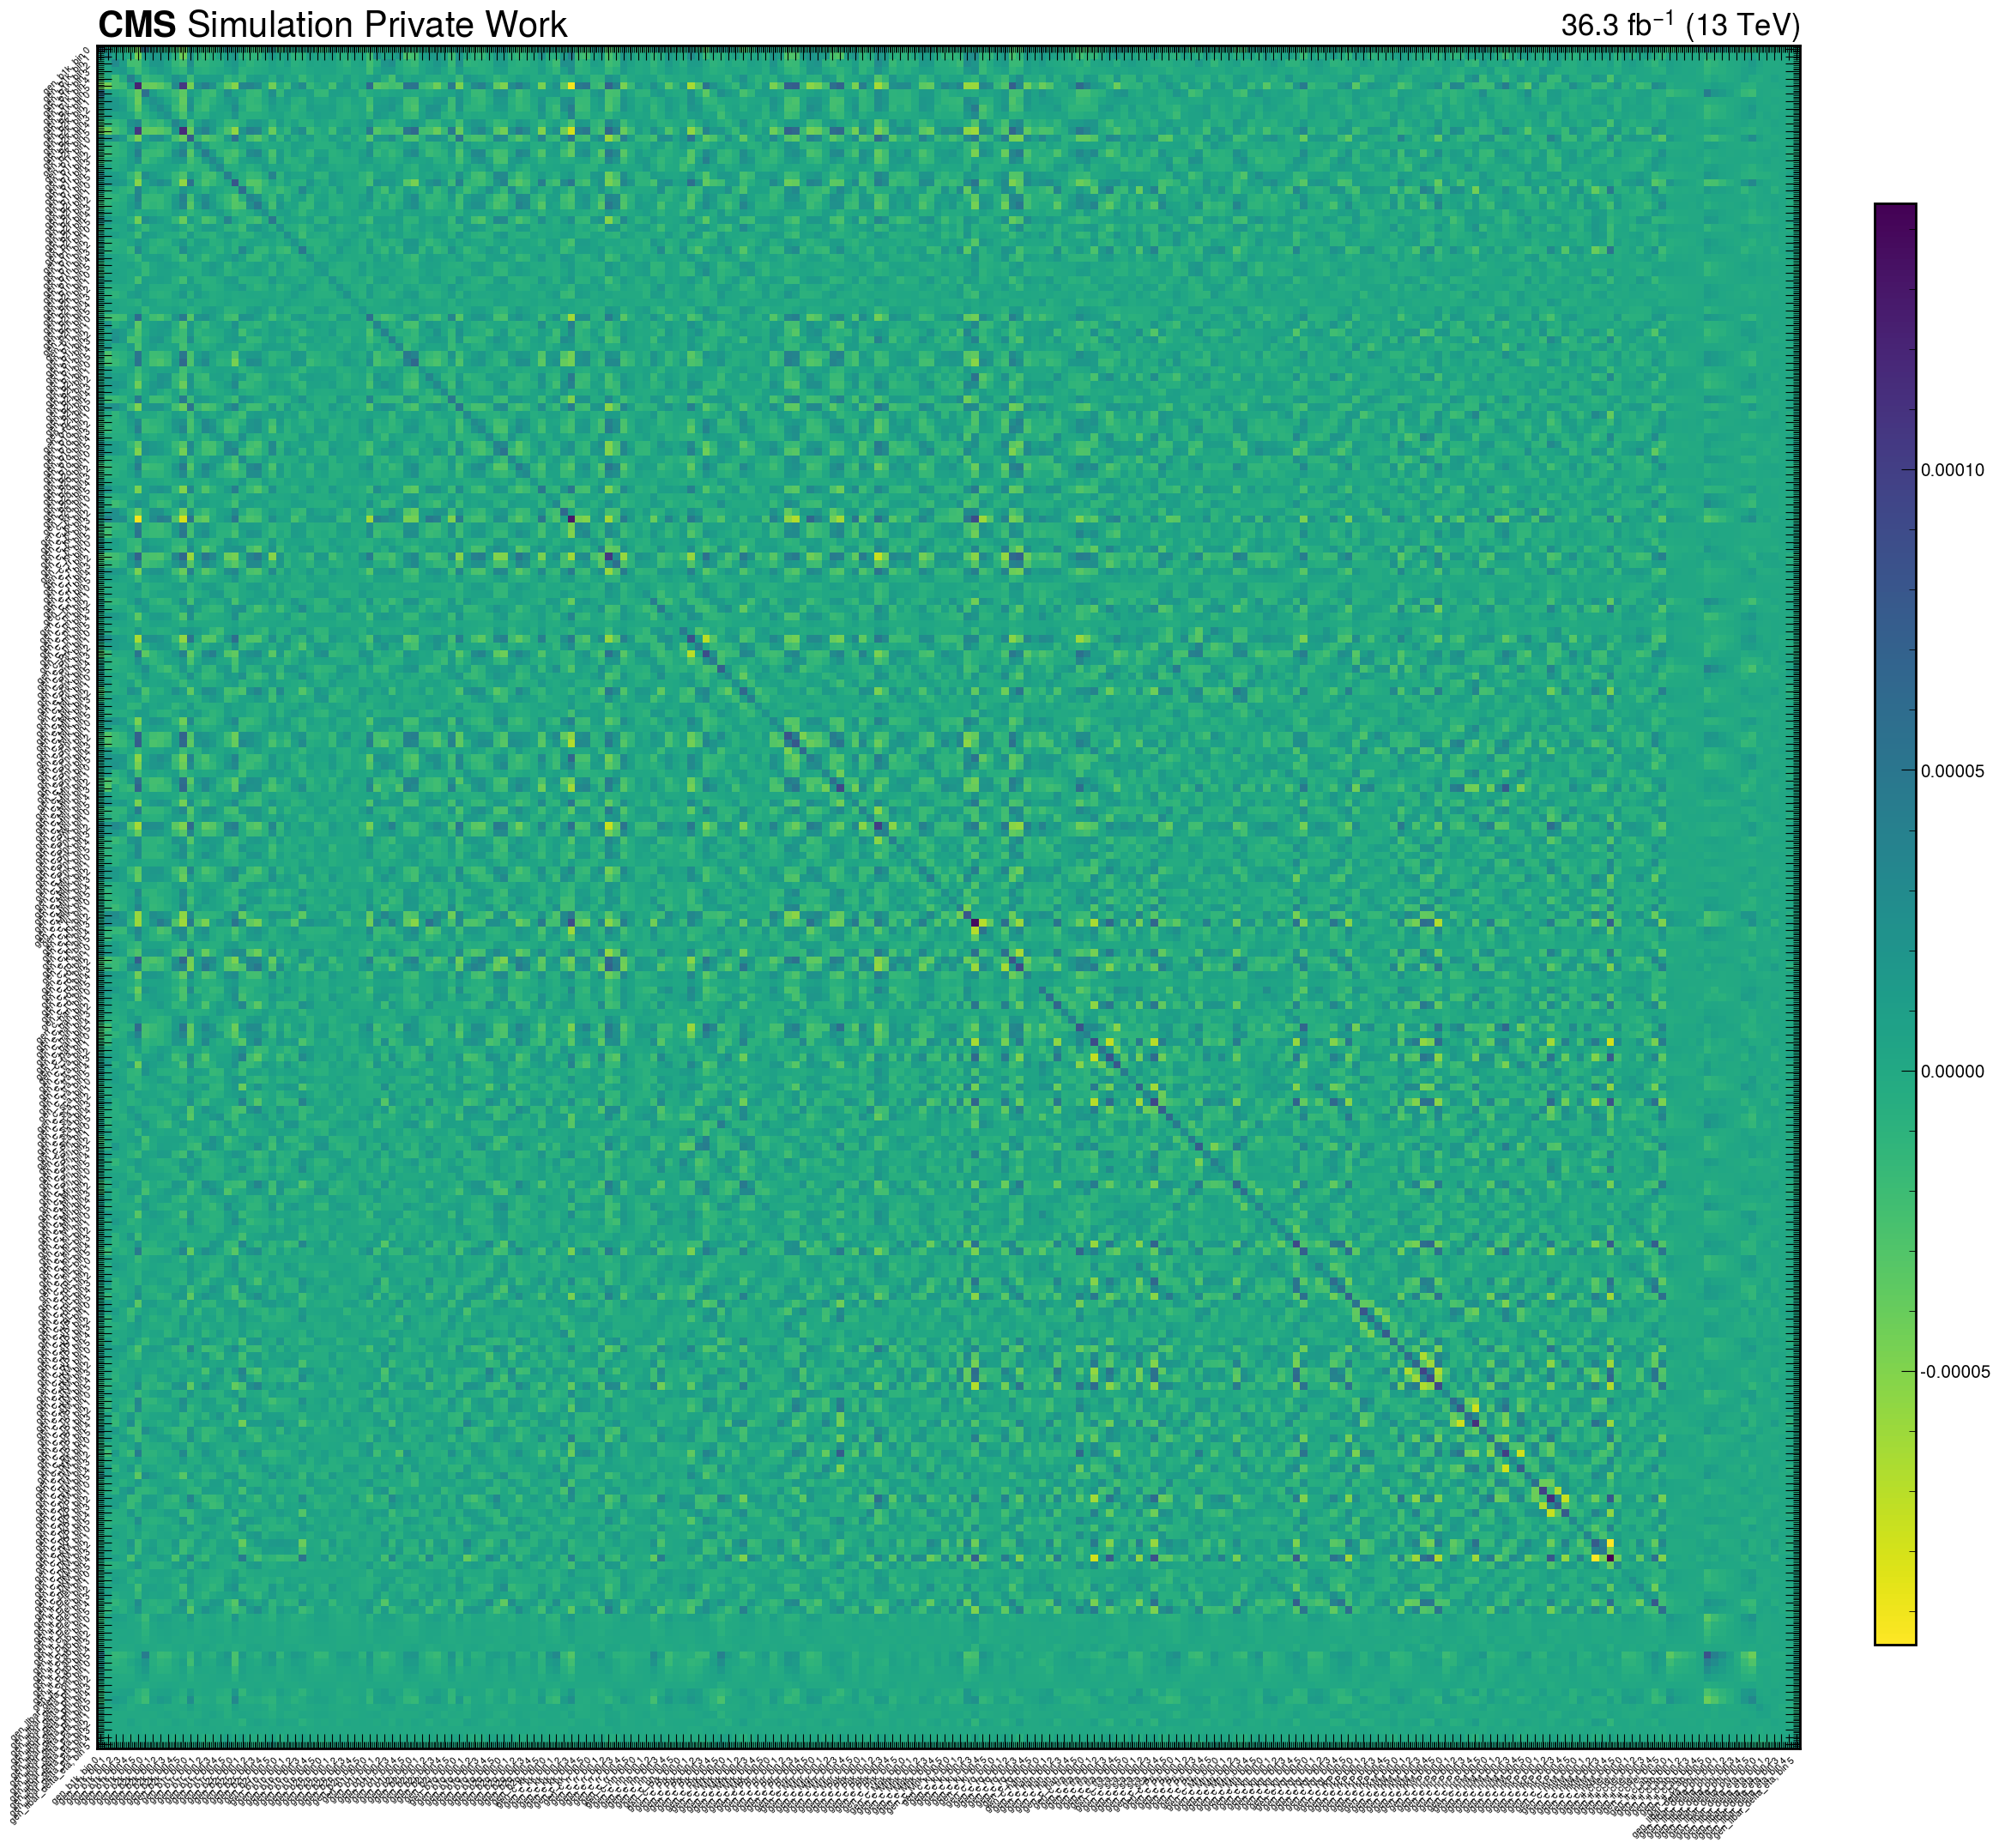

In [214]:
syst_cov_matrix = [] 
syst_cov_matrix = hist_syst["syst_1D_variables;1"]["CovMatrix_Norm"].array()

# Flip the matrix vertically
#syst_cov_matrix = np.flipud(syst_cov_matrix)

# Shape info
n_bins = len(syst_cov_matrix)

# Plotting
fig, axs = plt.subplots(1, 1, figsize=(24, 24))

im = axs.imshow(syst_cov_matrix, cmap='viridis_r')

axs.set_title(r"$\mathbf{CMS}$ Simulation Private Work", fontsize=30, loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")

axs.set_xticks(np.arange(n_bins))
axs.set_xticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

axs.set_yticks(np.arange(n_bins))
axs.set_yticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=15)

axs.set_ylim(n_bins - 0.5, -0.5)  # to keep y-axis in correct order

# Optional: save to PDF
plt.savefig('syst_matrix_from_root.pdf')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # adjust for colorbar
plt.show()

finalcov = np.add( stat_cov_matrix, syst_cov_matrix )
finalcov = finalcov 

bins_to_drop = [i for i in range(1, len(finalcov[0]), 6)]  # Starts at 1, skips every 6 bins
finalcov = np.delete(np.delete(finalcov, np.arange(1, len(finalcov[0]), 6), axis=0), np.arange(1, len(finalcov[1]), 6), axis=1)

# Define the bins to drop: the second bin of every 6-bin group

# observable_indices = np.array([10, 12, 13, 19])
# row_col_indices = np.concatenate([np.arange(i * 5, i * 5 + 5) for i in observable_indices])

# # Use np.ix_ to extract the submatrix
# finalcov = finalcov[np.ix_(row_col_indices, row_col_indices)]

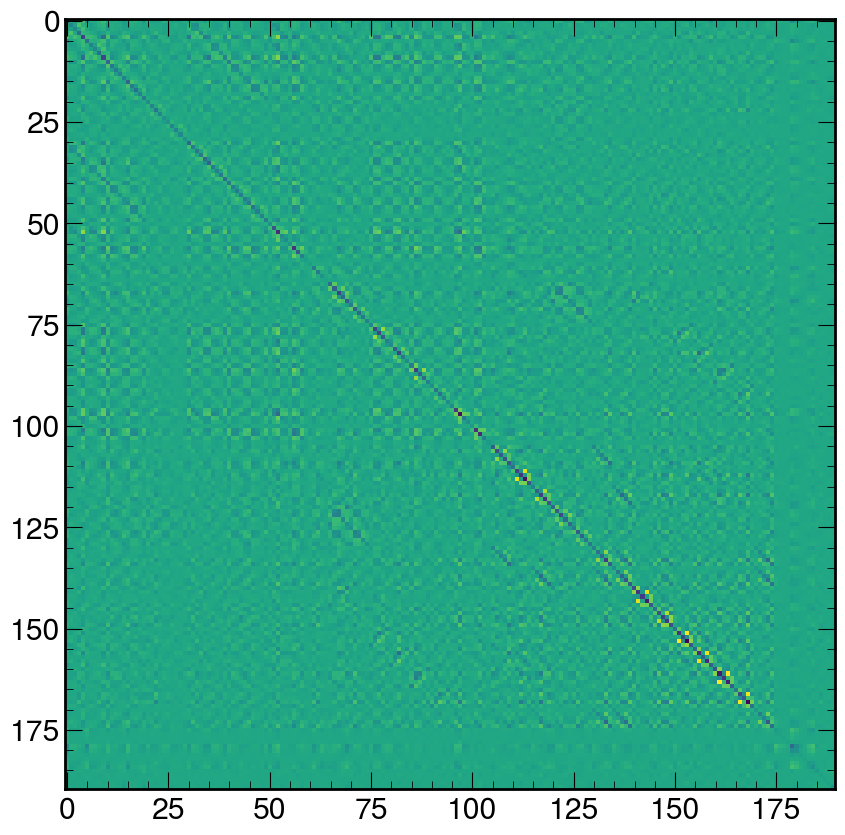

In [134]:
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
im = axs.imshow(finalcov, cmap='viridis_r')

# Prepare covariance matrix input for EFTFitter (almost there)

In [215]:
# Create a ROOT file and TH2F
root_file = ROOT.TFile("covariance_matrix/final_covariance_matrix.root", "RECREATE")
histogram = ROOT.TH2D("covariance_matrix", "Final Covariance Matrix", 
                      len(finalcov[0]), 0, len(finalcov[0]), len(finalcov[1]), 0, len(finalcov[1]))

# Fill the histogram with the matrix values
for i in range(len(finalcov[0])):
    for j in range(np.shape(finalcov)[0]):
        histogram.SetBinContent(i+1, j+1, finalcov[i, j])

# Write the histogram to the ROOT file
histogram.Write()

# Close the ROOT file
root_file.Close()

In [136]:
!ls ./covariance_matrix/ -ltrh

total 256K
-rw-r--r-- 1 he614 4360 121K Feb 25 19:46 statistical_covariance_matrix.root
-rw-r--r-- 1 he614 4360 265K Apr 22 00:45 final_covariance_matrix.root


In [296]:
hepdata_final_cov_matrix['covariance_matrix'].to_hist()

Hist(
  Regular(190, 0, 190, name='xaxis'),
  Regular(190, 0, 190, name='yaxis'),
  storage=Double()) # Sum: 0.006905553324611942

In [297]:
covmat.to_numpy

<bound method Histogram.to_numpy of Hist(
  Regular(190, 0, 190, name='xaxis'),
  Regular(190, 0, 190, name='yaxis'),
  storage=Double()) # Sum: 0.006905553324611942>

In [298]:
np.shape(covmat)

(190, 190)

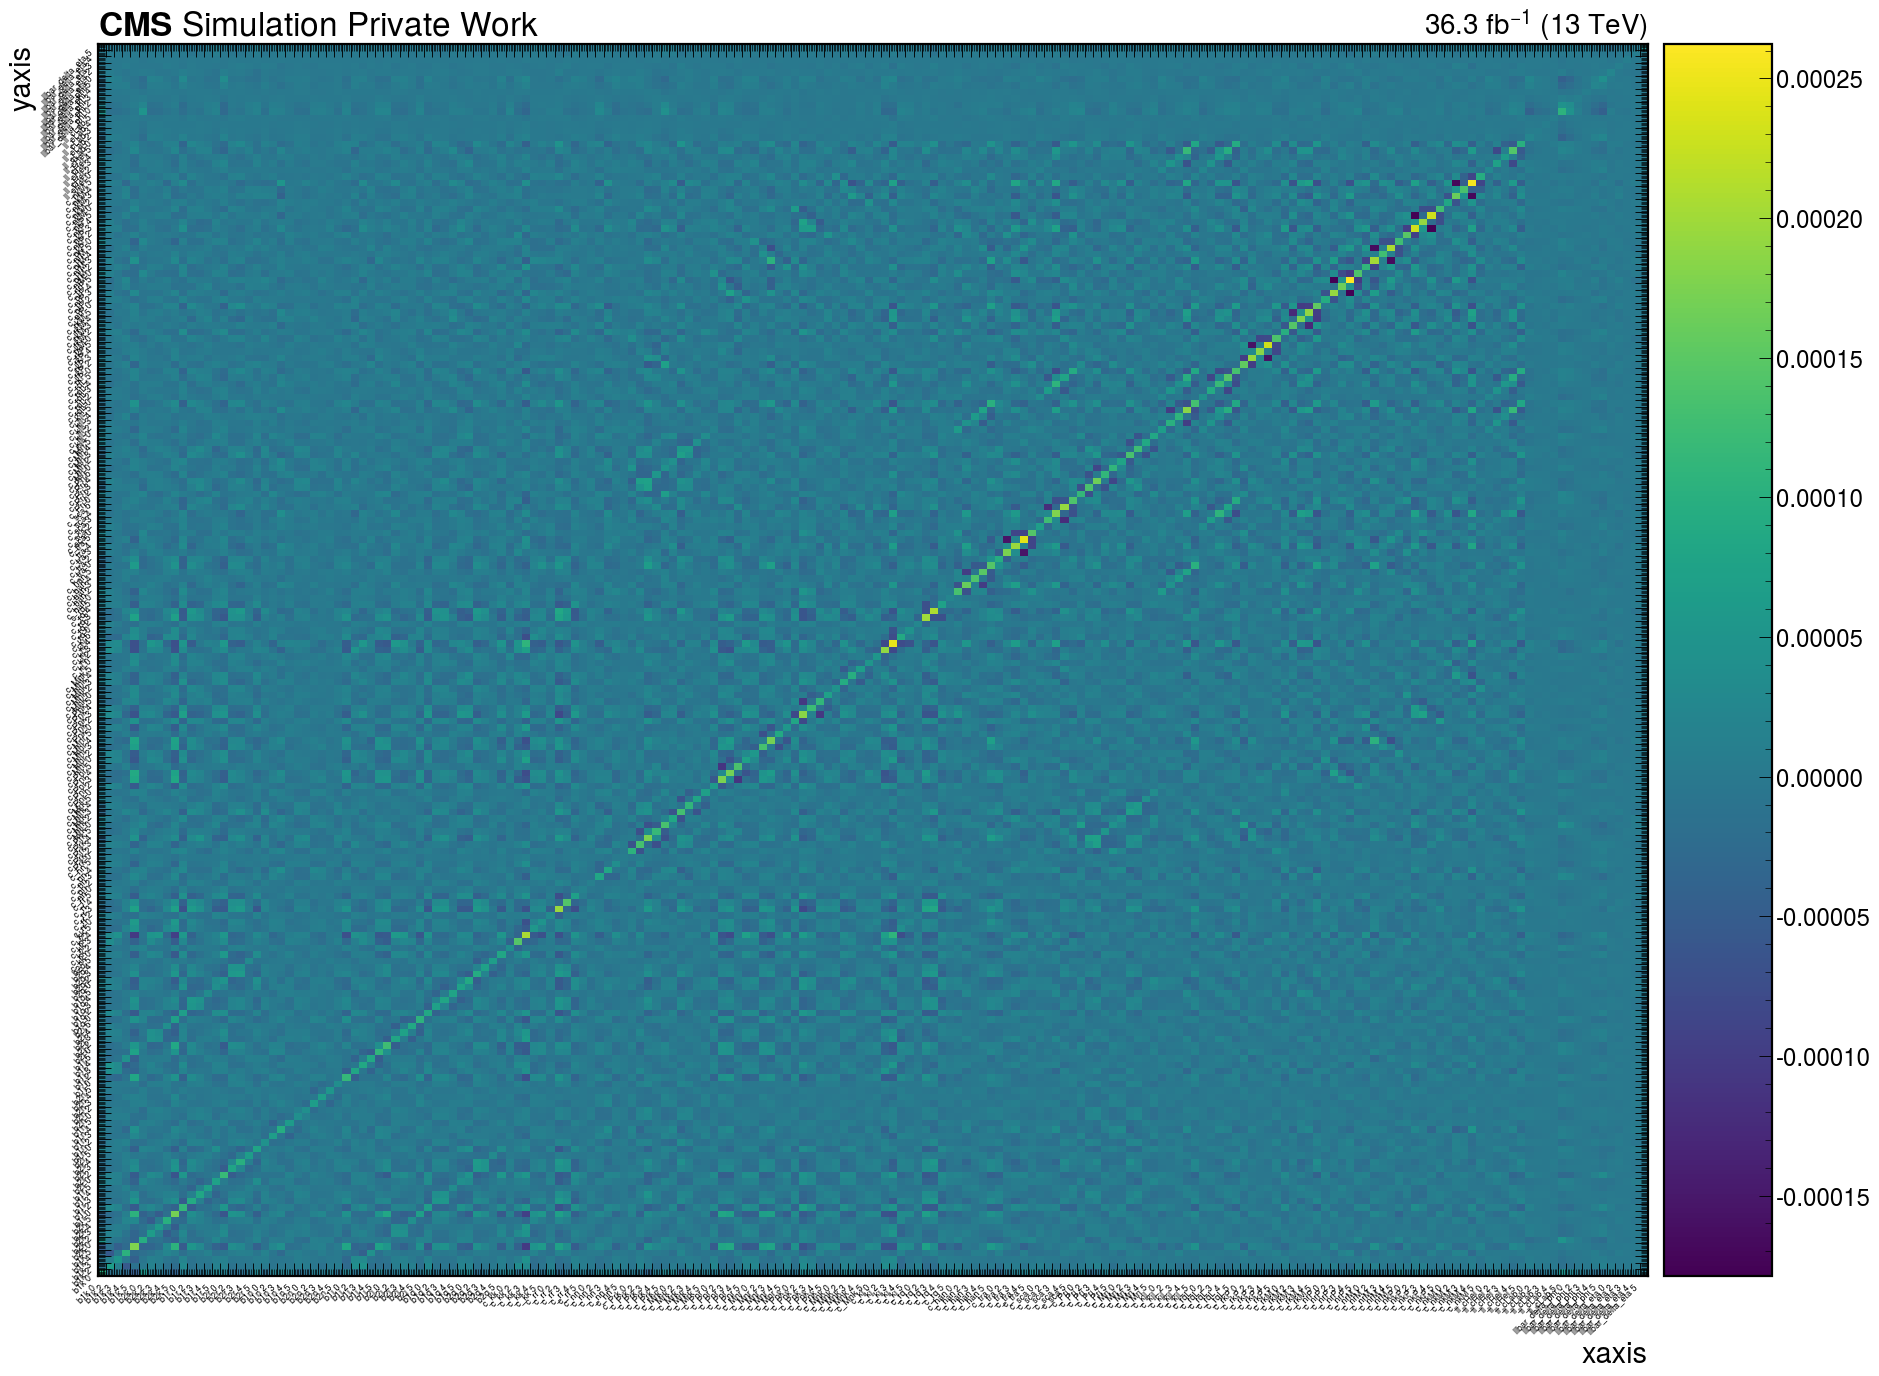

In [244]:
hepdata_final_cov_matrix = uproot.open("covariance_matrix/final_covariance_matrix.root")
hepdata_final_cov_matrix
covmat = hepdata_final_cov_matrix['covariance_matrix'].to_hist()

fig, axs = plt.subplots(1, 1, figsize=(25, 20), dpi=80) 
hepdata_final_cov_matrix['covariance_matrix'].to_hist().plot2d()

axs.set_title(r"$\mathbf{CMS}$ Simulation Private Work", fontsize=30, loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")

axs.set_yticks(np.arange(len(xy_labels_reduced)))
axs.set_yticklabels(xy_labels_reduced, rotation=45, ha='right', fontsize=8)

axs.set_xticks(np.arange(len(xy_labels_reduced)))
axs.set_xticklabels(xy_labels_reduced, rotation=45, ha='right', fontsize=8)
fig.savefig('finalcov.pdf')

Locator attempting to generate 1255 ticks ([-11.4, ..., 239.4]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1255 ticks ([-11.4, ..., 239.4]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1255 ticks ([-11.4, ..., 239.4]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1255 ticks ([-11.4, ..., 239.4]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1255 ticks ([-11.4, ..., 239.4]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1255 ticks ([-11.4, ..., 239.4]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1255 ticks ([-11.4, ..., 239.4]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1255 ticks ([-11.4, ..., 239.4]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1255 ticks ([-11.4, ..., 239.4]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1255 ticks ([-11.4, ..., 239.4]),

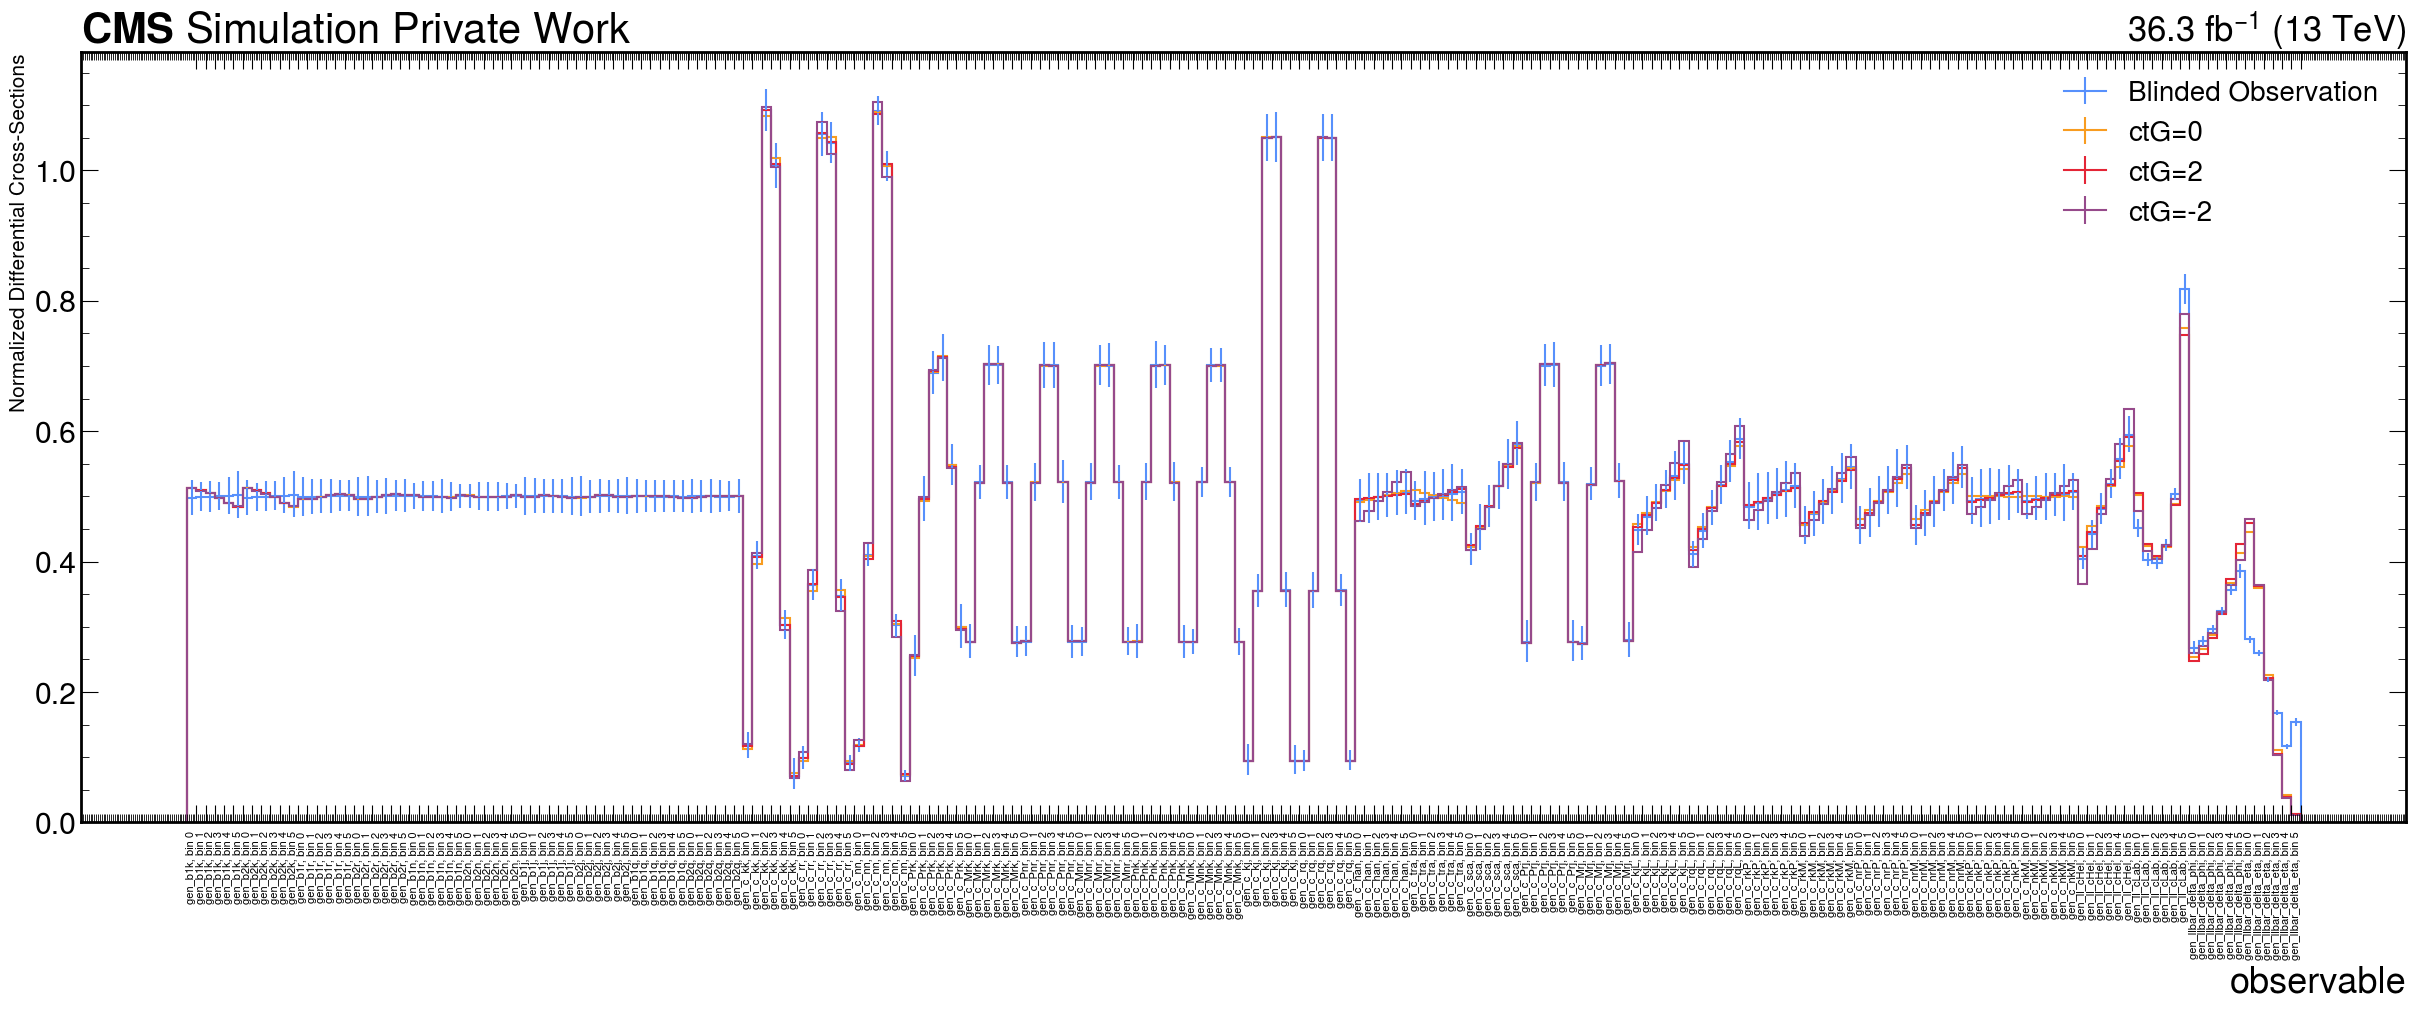

In [240]:
h_concatenated_EFT = {}

op_values = ['0', '2', '-2']

h_concatenated = uproot.open("concatenated_histograms.root")['diff_cross_section'].to_hist()
for value in op_values:
    h_concatenated_EFT[value] = uproot.open(f'concatenated_histograms_ctg{value}.root')['diff_cross_section'].to_hist()

fig, axs = plt.subplots(1, 1, figsize=(30, 10), dpi=100)

h_concatenated.plot1d(label='Blinded Observation')
for value in h_concatenated_EFT:
    h_concatenated_EFT[value].plot1d(label=f'ctG={value}')

axs.legend(fontsize=20)
axs.set_ylabel("Normalized Differential Cross-Sections", fontsize=15)
axs.set_xticks(np.arange(len(xy_labels))+1.0)
axs.set_xticklabels(xy_labels, rotation=90, ha='right', fontsize=8)

axs.set_title(r"$\mathbf{CMS}$ Simulation Private Work", fontsize=30, loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")
#axs.tight_layout()  # Automatically adjusts spacing
fig.savefig("concatenated_histograms.pdf", bbox_inches='tight')  # Ensures labels are not cut

# interpolate the values of a quadratic function as a function of op formed by these 3 histograms formed corresponding parameter op_values = ['p0', 'p2', 'm2']

In [329]:
cov_inv

array([[ 1.50556477e+06, -6.83003148e+05, -1.07607071e+05, ...,
        -3.49730082e+03, -1.36368112e+03, -8.32595669e+03],
       [-6.83003148e+05,  1.32424477e+06,  8.10648752e+05, ...,
        -3.52532028e+03, -1.05030680e+04,  1.17098439e+03],
       [-1.07607071e+05,  8.10648752e+05,  6.65477948e+05, ...,
        -8.13502744e+03, -1.54027553e+04, -4.56029390e+03],
       ...,
       [-3.49730082e+03, -3.52532028e+03, -8.13502744e+03, ...,
         2.62417307e+05,  1.10024934e+05,  1.05447557e+05],
       [-1.36368112e+03, -1.05030680e+04, -1.54027553e+04, ...,
         1.10024934e+05,  2.85829883e+05,  1.00433583e+05],
       [-8.32595669e+03,  1.17098439e+03, -4.56029390e+03, ...,
         1.05447557e+05,  1.00433583e+05,  1.21958292e+05]])

In [330]:
keep_indices

array([  0,   2,   3,   4,   5,   6,   8,   9,  10,  11,  12,  14,  15,
        16,  17,  18,  20,  21,  22,  23,  24,  26,  27,  28,  29,  30,
        32,  33,  34,  35,  36,  38,  39,  40,  41,  42,  44,  45,  46,
        47,  48,  50,  51,  52,  53,  54,  56,  57,  58,  59,  60,  62,
        63,  64,  65,  66,  68,  69,  70,  71,  72,  74,  75,  76,  77,
        78,  80,  81,  82,  83,  84,  86,  87,  88,  89,  90,  92,  93,
        94,  95,  96,  98,  99, 100, 101, 102, 104, 105, 106, 107, 108,
       110, 111, 112, 113, 114, 116, 117, 118, 119, 120, 122, 123, 124,
       125, 126, 128, 129, 130, 131, 132, 134, 135, 136, 137, 138, 140,
       141, 142, 143, 144, 146, 147, 148, 149, 150, 152, 153, 154, 155,
       156, 158, 159, 160, 161, 162, 164, 165, 166, 167, 168, 170, 171,
       172, 173, 174, 176, 177, 178, 179, 180, 182, 183, 184, 185, 186,
       188, 189, 190, 191, 192, 194, 195, 196, 197, 198, 200, 201, 202,
       203, 204, 206, 207, 208, 209, 210, 212, 213, 214, 215, 21

[Info] Using observables: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35], total bins: 170
Covariance matrix diagnostics:
  Shape: (170, 170)
  Diagonal min: 7.066e-06
  Diagonal max: 2.625e-04
  Condition number: 1.23e+05


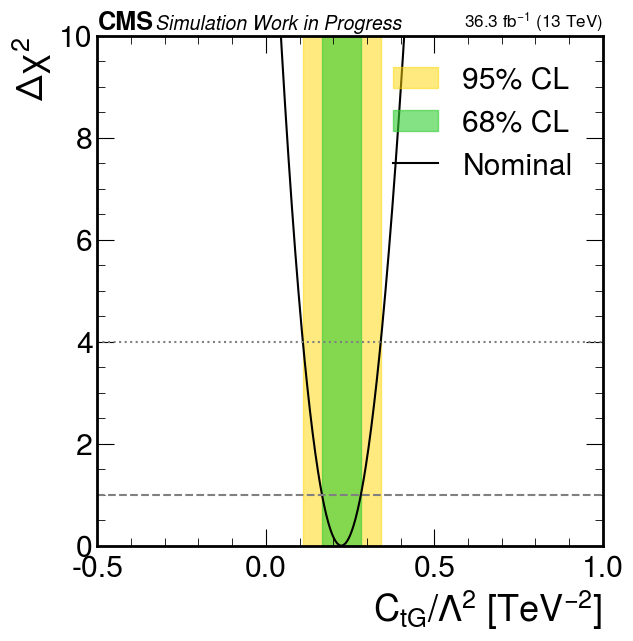


=== Confidence Interval Summary ===
Best fit value of C_G/Λ²: 0.224051
68% CL range         : [0.166614, 0.282220]
→ Width              : 0.115606
95% CL range         : [0.109845, 0.341205]
→ Width              : 0.231360

=== Δχ² Values for Input EFT Points ===
ctG = -8.0:  χ² = 3479.306505,  Δχ² = 3036.782920
ctG = -4.0:  χ² = 4391.055796,  Δχ² = 3948.532211
ctG = -2.0:  χ² = 2150.020465,  Δχ² = 1707.496881
ctG =  0.0:  χ² = 458.251630,  Δχ² = 15.728045
ctG =  2.0:  χ² = 959.158590,  Δχ² = 516.635005
ctG =  4.0:  χ² = 1708.503014,  Δχ² = 1265.979430
ctG =  8.0:  χ² = 4494.672283,  Δχ² = 4052.148698


In [223]:
# import uproot
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d

def normalize_cov_to_corr(covmat):
    diag = np.sqrt(np.diag(covmat))
    outer = np.outer(diag, diag)
    corrmat = covmat / outer
    corrmat[covmat == 0] = 0  # handle zero-variance entries safely
    return corrmat

# --- CMS Plot Style ---
plt.figure(figsize=(7, 7))
hep.style.use("CMS")

# --- Load EFT histograms ---
op_values = ['-8', '-4', '-2', '0', '2', '4', '8']
op_numeric = {
    "-8": -8.0, "-4": -4.0, "-2": -2.0,
    "0": 0.0, "2": 2.0, "4": 4.0, "8": 8.0
}
h_concatenated_EFT = {
    v: uproot.open(f'concatenated_histograms_ctg{v}.root')['diff_cross_section'].to_hist()
    for v in op_values
}
h_concatenated = uproot.open("concatenated_histograms.root")['diff_cross_section'].to_hist()

# --- Load full covariance matrix ---
covmat, _, _ = uproot.open("covariance_matrix/final_covariance_matrix.root")['covariance_matrix'].to_numpy()
n_cov_total = covmat.shape[0]

# --- Select observables to keep ---
#selected_observables = [9, 11, 12, 18]  # <<< EDIT THIS LIST to select other observables (0-based index)
selected_observables = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]  # <<< EDIT THIS LIST to select other observables (0-based index)
#selected_observables = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
block_structure = np.arange(228).reshape(-1, 6)  # 38 observables × 6 bins

# Drop 2nd bin (index 1) from each selected observable
keep_indices = []
for iobs in selected_observables:
    for ibin in range(6):
        if ibin != 1:
            keep_indices.append(block_structure[iobs, ibin])
keep_indices = np.array(keep_indices)

print(f"[Info] Using observables: {selected_observables}, total bins: {len(keep_indices)}")

# Build mapping from original 228-bin to compressed 190-bin
full_keep = []
for iobs in range(38):
    for ibin in range(6):
        if ibin != 1:
            full_keep.append(block_structure[iobs, ibin])
full_keep = np.array(full_keep)  # length = 190

# Build index remapping from original bin index to compressed 190-bin index
remap = {orig: new for new, orig in enumerate(full_keep)}

# Now remap keep_indices from 228-bin index to 190-bin index
mapped_indices = np.array([remap[i] for i in keep_indices])

# --- Reduce inputs based on selected bins ---
sm_vals = h_concatenated.values()[keep_indices]
sm_total = np.sum(sm_vals)

preds = {
    k: h.values()[keep_indices]
    for k, h in h_concatenated_EFT.items()
}

if (len(selected_observables)!=38):
    covmat = covmat[np.ix_(mapped_indices, mapped_indices)]

print("Covariance matrix diagnostics:")
print(f"  Shape: {covmat.shape}")
print(f"  Diagonal min: {np.min(np.diag(covmat)):.3e}")
print(f"  Diagonal max: {np.max(np.diag(covmat)):.3e}")
print(f"  Condition number: {np.linalg.cond(covmat):.2e}")
if np.any(np.diag(covmat) <= 0):
    raise ValueError("Covariance matrix has non-positive entries!")

cov_inv = np.linalg.inv(covmat)

# --- Interpolate EFT prediction per bin ---
def interpolate_prediction(wc):
    wc_vals = np.array([op_numeric[k] for k in op_values])
    pred_matrix = np.vstack([preds[k] for k in op_values])
    pred_interp = []
    for i in range(len(keep_indices)):
        coeffs = np.polyfit(wc_vals, pred_matrix[:, i], 5)
        pred_interp.append(np.polyval(coeffs, wc))
    return np.array(pred_interp)

# --- χ² function definition ---
def chi2(wc):
    pred = interpolate_prediction(wc)
    diff = sm_vals - pred
    #print("Ling: checking rel. diff.:", diff)
    return float(diff @ cov_inv @ diff)

# --- Fit and scan ---
res = minimize_scalar(chi2, bounds=(-10, 10), method='bounded')
wc_best = res.x
chi2_min = res.fun
#wc_grid = np.linspace(wc_best - 3, wc_best + 3, 200)
wc_grid = np.linspace(-10, 10, 10000)
chi2_vals = np.array([chi2(wc) for wc in wc_grid])
ndof = len(selected_observables)
dchi2_vals = (chi2_vals - chi2_min)

# Interpolate Δχ² to get confidence intervals
left_mask = wc_grid < wc_best
right_mask = wc_grid > wc_best
interp_left = interp1d(dchi2_vals[left_mask], wc_grid[left_mask],
                       kind='linear', bounds_error=False, fill_value='extrapolate')
interp_right = interp1d(dchi2_vals[right_mask], wc_grid[right_mask],
                        kind='linear', bounds_error=False, fill_value='extrapolate')
w1_lo = float(interp_left(1.0))
w1_hi = float(interp_right(1.0))
w2_lo = float(interp_left(4.0))
w2_hi = float(interp_right(4.0))

# --- Plotting ---
plt.axvspan(w2_lo, w2_hi, color='gold', alpha=0.5, label='95% CL')
plt.axvspan(w1_lo, w1_hi, color='limegreen', alpha=0.6, label='68% CL')
plt.plot(wc_grid, dchi2_vals, color='black', label='Nominal')
plt.axhline(1.0, color='gray', linestyle='--')
plt.axhline(4.0, color='gray', linestyle=':')

plt.xlabel(r'$C_{tG} / \Lambda^2$ [TeV$^{-2}$]')
plt.ylabel(r'$\Delta \chi^2$')
plt.ylim(0, 10)
plt.xlim(-0.5, 1)
plt.legend(loc='upper right')
hep.cms.text("Simulation Work in Progress", loc=0, fontsize=14)
hep.cms.lumitext("36.3 fb$^{-1}$ (13 TeV)", fontsize=13)
plt.tight_layout()
plt.savefig("ctG_subsetObs_DeltaChi2.pdf")
plt.show()

# --- Summary ---
print("\n=== Confidence Interval Summary ===")
print(f"Best fit value of C_G/Λ²: {wc_best:.6f}")
print(f"68% CL range         : [{min(w1_lo, w1_hi):.6f}, {max(w1_lo, w1_hi):.6f}]")
print(f"→ Width              : {abs(w1_hi - w1_lo):.6f}")
print(f"95% CL range         : [{min(w2_lo, w2_hi):.6f}, {max(w2_lo, w2_hi):.6f}]")
print(f"→ Width              : {abs(w2_hi - w2_lo):.6f}")

print("\n=== Δχ² Values for Input EFT Points ===")
for label, wc_val in op_numeric.items():
    chi2_val = chi2(wc_val)
    delta_chi2 = chi2_val - chi2_min
    print(f"ctG = {wc_val:>4}:  χ² = {chi2_val:.6f},  Δχ² = {delta_chi2:.6f}")


In [233]:
!ls debug_fit_inputs.root -ltrh

-rw-r--r-- 1 he614 4360 5.9K Apr 22 16:32 debug_fit_inputs.root


In [241]:
debug_hist = uproot.open('debug_fit_inputs.root')

In [242]:
debug_hist.keys()

['h_data;1', 'h_model;1']

/depot/cms/kernels/coffea_latest/lib/python3.12/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/depot/cms/kernels/coffea_latest/lib/python3.12/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fdf5e0ac0b0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

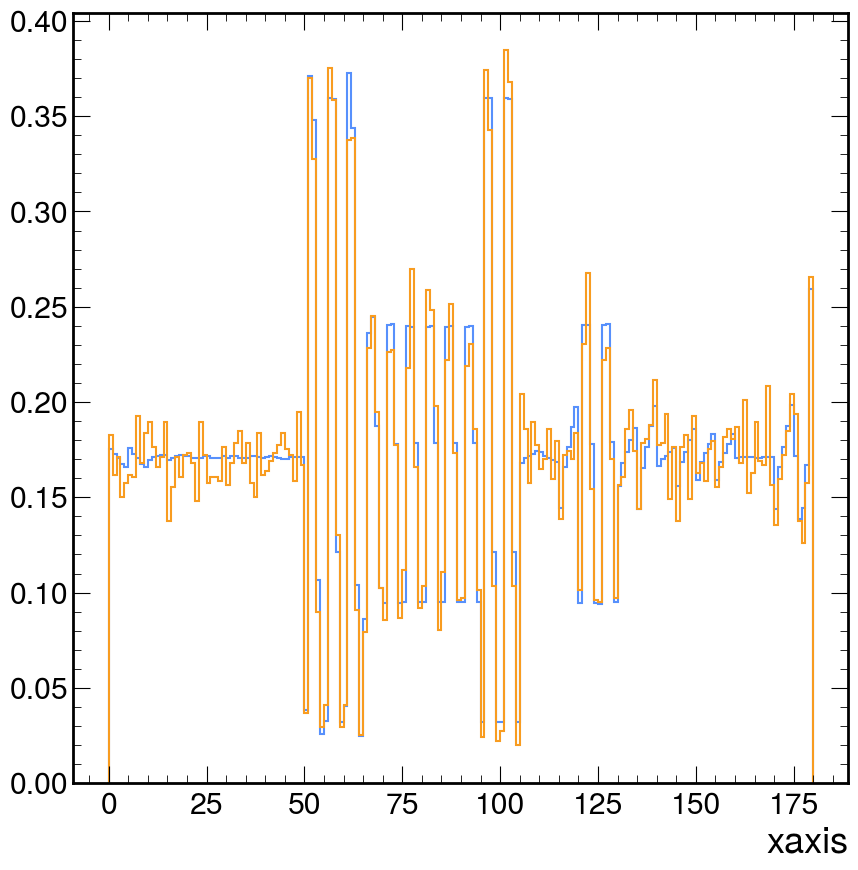

In [243]:
debug_hist['h_model;1'].to_hist().plot1d()
debug_hist['h_data;1'].to_hist().plot1d()